# Class 6: Data Science — Pandas & Regressions


Goals of today's class:
1. Get comfortable using `pandas` for tabular data
2. Join tables, and turn them into a network
3. Understand how regressions work at a very high level.

*Acknowledgement: This lesson is adapted from one written by [Alyssa Smith](https://asmithh.github.io/), who co-taught this course in 2024.*
________

## Getting today's notebook

**Every class, duplicate the notebook before you run anything, and work in the copy.** Running a cell changes the file, and a changed original can block your next pull.

1. Log in to [Open OnDemand](https://ood.explorer.northeastern.edu/), open the **Courses** menu, and click **JupyterLab (Python)**. Launch it with the same settings as last class; they should already be filled in.
2. Once JupyterLab starts, open a terminal (**File → New → Terminal**) and pull the new material, where `USERNAME` is your Northeastern username:
   ```bash
   cd /courses/NETS7052.202710/students/USERNAME/nets7052_fa26
   git fetch upstream
   git checkout main
   git merge --no-edit upstream/main
   ```
   Once you've committed work of your own to your fork (Assignment 1, for example), this merge needs a commit message. `--no-edit` lets Git write that message itself instead of opening a text editor in your terminal.
3. **Duplicate today's notebook before you run anything.** In the file browser, open `notebooks/class_06_data_science/`, right-click `class_06_data_science.ipynb`, and choose **Duplicate**. Open the copy (`class_06_data_science-Copy1.ipynb`) and work there.
4. Check that the top-right corner of the notebook says **Python (cmns-core)**. If it doesn't, choose **Kernel → Change Kernel…** and pick it.

**If the merge doesn't work:**

- *"Your local changes to the following files would be overwritten by merge"*: you changed a notebook that I've since updated, and Git lists which one. If you took notes in it, duplicate it first. Then close it and reset it, using the path Git listed:
  ```bash
  git restore notebooks/class_05_scraping/class_05_scraping.ipynb
  ```

  `git restore` throws away every change you made to that one file and puts back the version from your last pull. Git can't undo it, which is why you duplicate first. Then run `git merge --no-edit upstream/main` again.
- *"'upstream' does not appear to be a git repository"*: you missed a step in Class 0. Run this, then start again from `git fetch upstream`:
  ```bash
  git remote add upstream https://github.com/computational-methods-network-science/nets7052_fa26.git
  ```
- **Git asks for a GitHub username or password:** don't type them. Your `upstream` address is wrong. Run this, then start again from `git fetch upstream`:
  ```bash
  git remote set-url upstream https://github.com/computational-methods-network-science/nets7052_fa26.git
  ```

## Pandas
*Adapted from [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)*

### What is `pandas`?
At a basic level, `pandas` is a Python library for manipulating & analyzing data. It's best for *tabular data*, which is data that can nicely be organized into a table with rows and columns. Tabular data could look like:
* sales from an ecommerce site (each row is a sale, and the columns hold information about the sale -- product(s), time of sale, dollar amount of the purchase, etc.)
* a robot's position as it changes over time (each row has a timestamp and x, y, and z coordinates indicating the robot's location)
* bikeshare trips (each row is an individual trip with source and destination stations, timestamps, and trip duration)

Sometimes it's okay to store network data in a tabular format; other times, when we're running (e.g.) spreading simulations or network reconstruction, a tabular format is not very helpful. 

Today, we're going to be working with non-network tabular data for the most part -- it's easier to get a handle on `pandas` this way. 

We usually import `pandas` like this:

In [3]:
import pandas as pd

### Basic `pandas` structures
`pandas` has two basic units that we care about: a `Series` and a `DataFrame`. `Series` are roughly akin to lists -- they're one-dimensional and can hold data of any type. `DataFrames` are two-dimensional (they have rows and columns) and are indexed by one or more columns. This means that a row can be identified by the labels in the index column. Each column of a `DataFrame` is also a `Series`. 

We'll focus on `DataFrames` for now. We can populate a `DataFrame` in a few different ways. First, let's instantiate a `DataFrame` with our own data.

In [4]:
df = pd.DataFrame({
    "Name": ["Orca", "Blue Whale", "Beluga Whale", "Narwhal"],
    "Weight": [22000, 441000, 2530, 3500],
    "Cute":[True, True, True, True],
    "Habitat": ["Everywhere", "Everywhere", "Arctic", "Arctic"],
})

Let's look at the types the columns of our `DataFrame` `df` have: 

In [5]:
df.dtypes

Name         str
Weight     int64
Cute        bool
Habitat      str
dtype: object

Wow! These are a lot of different types! Having the incorrect type in your columns can (occasionally) be an issue, but `pandas` is pretty good at converting columns between types. 

#### Adding A Column
Let's practice adding a new column by converting an existing column's type. We add new columns like we would add an entry in a Python dictionary. We can also access columns in a `DataFrame` as attributes of the object (e.g. `df.column`). Then we can convert the type using `df.column.astype(TYPE)`:

In [6]:
df['cute_numeric'] = df.Cute.astype(int)
df

,Name,Weight,Cute,Habitat,cute_numeric
0,Orca,22000,True,Everywhere,1
1,Blue Whale,441000,True,Everywhere,1
2,Beluga Whale,2530,True,Arctic,1
3,Narwhal,3500,True,Arctic,1


We can also add a column of our own devising to the dataframe -- as long as it's the same length as the existing dataframe:

In [7]:
df["Food"] = ["Everything", "Krill", "Squid, Clams, Octopus, Cod, Herring", "Fish"]


We can  access all the column names like this:

In [8]:
df.columns

Index(['Name', 'Weight', 'Cute', 'Habitat', 'cute_numeric', 'Food'], dtype='str')

or see the first 3 entries like this:

In [9]:
df.head(3)

,Name,Weight,Cute,Habitat,cute_numeric,Food
0,Orca,22000,True,Everywhere,1,Everything
1,Blue Whale,441000,True,Everywhere,1,Krill
2,Beluga Whale,2530,True,Arctic,1,"Squid, Clams, Octopus, Cod, Herring"


## Common `pandas` operations
### Sorting
Now we'll practice some common operations in `pandas`. One thing we might want to do is sort a dataframe by a particular column. We can indicate which column to sort by using the `by` keyword argument. If we want it in reverse order (as opposed to regular ascending order), we set the `ascending` keyword argument to `False`:

In [10]:
df.sort_values(by="Weight", ascending=False)

,Name,Weight,Cute,Habitat,cute_numeric,Food
1,Blue Whale,441000,True,Everywhere,1,Krill
0,Orca,22000,True,Everywhere,1,Everything
3,Narwhal,3500,True,Arctic,1,Fish
2,Beluga Whale,2530,True,Arctic,1,"Squid, Clams, Octopus, Cod, Herring"


Can you sort the dataframe alphabetically by species name? 

In [9]:
# Your turn!!!

### Filtering
Another common thing we can do in `pandas` is filtering. This means we only select the rows that match a specific condition. Let's filter for all the cetaceans (umbrella term for whales, dolphins, and porpoises) whose weight is over 5000 pounds. Here, again, we're using a dictionary-like syntax to filter the data. Filtering conditions should be boolean; you can also combine multiple conditions if you're feeling fancy.

In [11]:
df[df.Weight > 5000]

,Name,Weight,Cute,Habitat,cute_numeric,Food
0,Orca,22000,True,Everywhere,1,Everything
1,Blue Whale,441000,True,Everywhere,1,Krill


Can you filter the data to find all the cetaceans that live in the Arctic?


In [11]:
# Your turn!!

#### Changing values in some rows
To change values only in the rows that match a condition, use `.loc[rows, column]`, which picks the rows and the column in one step. Filtering first and then assigning, as in `df[df.Weight > 5000]['Weight'] = 0`, is called *chained assignment*, and it never works: the filter makes a new DataFrame, the assignment changes that copy, and your original is untouched. `pandas` warns you, but a warning is easy to scroll past.

In [12]:
df2 = df.copy()
df2[df2.Weight > 5000]['Weight'] = 0        # chained: the filter makes a copy, and only the copy changes
print(df2.Weight.tolist())

df2.loc[df2.Weight > 5000, 'Weight'] = 0    # .loc: rows and column in one step, so df2 itself changes
print(df2.Weight.tolist())

[22000, 441000, 2530, 3500]
[0, 0, 2530, 3500]


/tmp/ipykernel_880975/1430264691.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  df2[df2.Weight > 5000]['Weight'] = 0        # chained: the filter makes a copy, and only the copy changes


### Applying functions to columns
We can create and modify existing columns using the `apply` function. Any function that takes in a single argument and returns something (ideally something that fits nicely into a `pandas` column) is fair game. Let's try an example:

In [13]:
def convert_from_lbs_to_kg(wt):
    return wt * 0.45
df["Weight_kg"] = df["Weight"].apply(convert_from_lbs_to_kg)

When we apply a function, we can use an actual function, as we did above, or we can use an __anonymous function__, or a "lambda function". It must use a single expression to modify its input (and the expression can involve functions): `lambda INPUT: np.sqrt(INPUT) + 5` is a valid example. 

In [14]:
df["Weight_tons"] = df["Weight"].apply(lambda b: b / 2000)

For arithmetic like this you don't need `apply` at all. Math on a column acts on every value at once, and on a big table it's much faster than calling a Python function once per row. Save `apply` for functions that can't be written that way.

In [15]:
df["Weight_kg"] = df["Weight"] * 0.45    # the same column as before, without apply
df.head()

,Name,Weight,Cute,Habitat,cute_numeric,Food,Weight_kg,Weight_tons
0,Orca,22000,True,Everywhere,1,Everything,9900.0,11.000
1,Blue Whale,441000,True,Everywhere,1,Krill,198450.0,220.500
2,Beluga Whale,2530,True,Arctic,1,"Squid, Clams, Octopus, Cod, Herring",1138.5,1.265
3,Narwhal,3500,True,Arctic,1,Fish,1575.0,1.750


### Grouping

We also might want to group our dataframe into chunks that have something in common. This is a good way to look at aggregate information for particular types of items. For example, if you are looking at a table of patients' health outcomes, you might be interested in aggregating outcomes by the cities in which patients reside. 

To do this, we  use the `groupby` operator. When we group by a column (or multiple), `pandas` returns an iterable of tuples; each tuple consists of a unique value that the column(s) take(s) and a `DataFrame` with all the rows that have that value in the relevant column(s). Let's see what this looks like in practice!

In [16]:
groups = df.groupby('Habitat')
for habitat, df_gr in groups:
    print(habitat)
    print(df_gr.head())

Arctic
           Name  Weight  Cute Habitat  cute_numeric  \
2  Beluga Whale    2530  True  Arctic             1   
3       Narwhal    3500  True  Arctic             1   

                                  Food  Weight_kg  Weight_tons  
2  Squid, Clams, Octopus, Cod, Herring     1138.5        1.265  
3                                 Fish     1575.0        1.750  
Everywhere
         Name  Weight  Cute     Habitat  cute_numeric        Food  Weight_kg  \
0        Orca   22000  True  Everywhere             1  Everything     9900.0   
1  Blue Whale  441000  True  Everywhere             1       Krill   198450.0   

   Weight_tons  
0         11.0  
1        220.5  


Here, we're grouping our dataframe by the `Habitat` column. `groups` is an iterable (we can iterate over the items in it, in the order given to us) that has two variables. One of them is the unique value of the column we grouped by (`Everywhere` and `Arctic`) and the other one is the chunk of the dataframe that had that unique value in that column. 

Can you group the cetaceans that weigh more than 5000 pounds apart from the ones that weigh less than 5000 pounds? (Hint: You might have to create a new column!)

In [17]:
# Your Turn!!!

Looping over the groups shows you what `groupby` does. Most of the time, though, you want a number or two per group, and `agg` gives you a table of them directly:

In [17]:
df.groupby('Habitat')['Weight'].agg(['mean', 'max', 'count'])

,mean,max,count
Habitat,,,
Arctic,3015.0,3500,2
Everywhere,231500.0,441000,2


## Practicing with Pandas
We can also load a pandas dataframe from a `.csv` (comma separated values) file. We're going to load up `WhaleFromSpaceDB_Whales.csv`, which we sourced from the [UK Polar Data Centre](https://ramadda.data.bas.ac.uk/repository/entry/show?entryid=c1afe32c-493c-4dc7-af9f-649593b97b2c)

In [19]:
df_whales = pd.read_csv('./data/WhaleFromSpaceDB_Whales.csv')
print(df_whales.head(5))
print(df_whales.columns)

              MstLklSp SpAbbr PtlOtrSp  BoL  BoW  BoS  BoC  FlukeP  Blow  \
0  Eubalaena australis    SRW      NaN    2    1    1    2       0     0   
1  Eubalaena australis    SRW      NaN    2    1    1    2       0     0   
2  Eubalaena australis    SRW      NaN    1    1    1    2       0     0   
3  Eubalaena australis    SRW      NaN    1    1    1    2       0     0   
4  Eubalaena australis    SRW      NaN    1    1    1    2       0     0   

   Contour  ...        Long   ImageID  \
0        0  ...  166.281952  1.01E+15   
1        0  ...  166.278841  1.01E+15   
2        0  ...  166.274348  1.01E+15   
3        0  ...  166.291132  1.01E+15   
4        0  ...  166.268754  1.01E+15   

                                      ImageFile  ImageDate  Satellite  \
0  06AUG12231250-P2AS-052609152010_01_P001+M2AS   20060812        QB2   
1  06AUG12231250-P2AS-052609152010_01_P001+M2AS   20060812        QB2   
2  06AUG12231250-P2AS-052609152010_01_P001+M2AS   20060812        QB2   
3  0

### A first look
Before you analyze a new dataset, look at what's in it. `info()` lists every column with its type and how many values it has (fewer than the number of rows means some are missing), and `describe()` summarizes the numeric columns:

In [20]:
df_whales.info()

<class 'pandas.DataFrame'>
RangeIndex: 633 entries, 0 to 632
Data columns (total 34 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MstLklSp         633 non-null    str    
 1   SpAbbr           633 non-null    str    
 2   PtlOtrSp         1 non-null      str    
 3   BoL              633 non-null    int64  
 4   BoW              633 non-null    int64  
 5   BoS              633 non-null    int64  
 6   BoC              633 non-null    int64  
 7   FlukeP           633 non-null    int64  
 8   Blow             633 non-null    int64  
 9   Contour          633 non-null    int64  
 10  Wake             633 non-null    int64  
 11  AfterB           633 non-null    int64  
 12  Defecation       633 non-null    int64  
 13  MudTrail         633 non-null    int64  
 14  OtherDistu       633 non-null    int64  
 15  Fluke            633 non-null    int64  
 16  Flipper          633 non-null    int64  
 17  HeadCalosi       633 non-nu

In [21]:
df_whales.describe()

,BoL,BoW,BoS,BoC,FlukeP,Blow,Contour,Wake,AfterB,Defecation,...,OtherDistu,Fluke,Flipper,HeadCalosi,Movement,ClassScore,Lat,Long,ImageDate,NumWhale
count,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,...,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,633.000000,6.330000e+02,633.000000
mean,1.423381,1.246445,1.333333,1.424961,0.143760,0.050553,0.208531,0.069510,0.033175,0.006319,...,0.826224,0.105845,0.031596,0.499210,0.018957,6.508689,-23.750579,-25.529577,2.013061e+07,1.202212
std,0.777994,0.745826,0.729863,0.718963,0.477198,0.265000,0.563210,0.339726,0.232975,0.112331,...,0.866833,0.401556,0.200348,0.653919,0.193945,3.239809,32.010725,97.498086,3.555840e+04,0.401967
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,-50.559498,-156.860322,2.006081e+07,1.000000
25%,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.500000,-42.595484,-64.692489,2.011083e+07,1.000000
50%,2.000000,1.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,6.500000,-42.530394,-64.409904,2.014102e+07,1.000000
75%,2.000000,2.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.000000,1.000000,0.000000,8.500000,20.850436,20.897661,2.016092e+07,1.000000
max,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,17.000000,43.182916,166.338153,2.017022e+07,2.000000


### Exploring
Notice in that summary that `Fluke` goes up to 2: it isn't a yes/no column, which matters for the exercise below. Now let's explore the dataset a little bit! The `value_counts` function tells us how many times each unique value showed up in a column. It returns a nice dictionary-like object.

In [22]:
df_whales['MstLklSp'].value_counts()

MstLklSp
Eubalaena australis       463
Eschrichtius robustus      80
Megaptera novaeangliae     56
Balaenoptera physalus      34
Name: count, dtype: int64

Now let's check for flukes, or whales' tails! Flukes are valuable to marine biologists because they help them visually identify individuals. Whale flukes are analogous to human fingerprints in terms of their uniqueness. For each whale species, can you count how many times flukes were and were not seen?

We have a column, `Certainty2`, that tells us how certain the identification of a whale was. 
Let's assign numeric values to each of the identification values. We'll say `Definite = 1.0`, `Probable = 0.8`, and `Possible = 0.6`. 
What is the average certainty for each species? (Hint: `df.column.mean()` gives the average value of a column, and you'll have to use the `apply` function to create a numeric column for certainty!)

In [24]:
# Your Turn!!!

def certaintymap(str_cert):
    if str_cert == 'Definite':
        return 1.0
    elif str_cert == 'Probable':
        return 0.8
    elif str_cert == 'Possible':
        return 0.6
    else:
        return None

In [26]:
# Your Turn!!!

df_whales['CertaintyNum'] = df_whales['Certainty2'].apply(certaintymap)
df_whales.groupby('MstLklSp')['CertaintyNum'].mean()

MstLklSp
Balaenoptera physalus     0.923529
Eschrichtius robustus     0.840000
Eubalaena australis       0.776242
Megaptera novaeangliae    0.782143
Name: CertaintyNum, dtype: float64

### Break

## Joining tables: from two tables to a network
Network data often comes as two tables: one with information about the nodes, and one listing the edges. Here's a food web from Florida Bay as two files. `Florida-bay-meta.csv` has a row for each of its 128 compartments, mostly species, and `Florida-bay.txt` lists its 2,106 directed edges. An edge `(i, j)` means carbon flows from `i` to `j`, so a whale eating krill would be `(krill, whale)`.

In [27]:
species = pd.read_csv('data/Florida-bay-meta.csv')
foodweb = pd.read_csv('data/Florida-bay.txt', sep=r'\s+', comment='#',
                      names=['FromNodeId', 'ToNodeId'])
print(species.shape, foodweb.shape)
species.head()

(128, 3) (2106, 2)


,node_id,name,group
0,0,2um Spherical Phytoplankt,NaN
1,1,Synedococcus,NaN
2,2,Oscillatoria,NaN
3,3,Small Diatoms (<20um),NaN
4,4,Big Diatoms (>20um),NaN


### Missing values
Before joining anything, look at what's in the columns. How many compartments are in each `group`?

In [28]:
species['group'].value_counts(dropna=False)

group
NaN                             66
Macroinvertebrates              21
Pelagic Fishes                   8
Benthic Fishes                   7
Zooplankton Microfauna           6
Demersal Fishes                  5
Seagrass Producer                3
Microbial Microfauna             3
Sediment Organism Microfauna     3
Detritus                         3
Algae Producer                   2
Demersal Producer                1
Name: count, dtype: int64

Half the compartments have no group at all (`NaN` means the value is missing), including the sharks, the dolphins, and the crocodiles. `value_counts()` leaves missing values out unless you pass `dropna=False`, so it's easy to never notice them. Let's give them a label of their own:

In [30]:
species['group'] = species['group'].fillna('Unassigned')
species

,node_id,name,group
0,0,2um Spherical Phytoplankt,Unassigned
1,1,Synedococcus,Unassigned
2,2,Oscillatoria,Unassigned
3,3,Small Diatoms (<20um),Unassigned
4,4,Big Diatoms (>20um),Unassigned
...,...,...,...
123,123,Benthic POC,Detritus
124,124,DOC,Unassigned
125,125,Input,Detritus
126,126,Output,Unassigned


### Merging
The edge table only has IDs. To find out who's doing the eating, we attach the species table to it with `pd.merge`, matching `ToNodeId` in the edges to `node_id` in the species table. By default this is an *inner join*: it keeps only the rows that have a match in both tables.

In [31]:
eaters = pd.merge(foodweb, species, left_on='ToNodeId', right_on='node_id')
eaters.head()

,FromNodeId,ToNodeId,node_id,name,group
0,125,0,0,2um Spherical Phytoplankt,Unassigned
1,125,1,1,Synedococcus,Unassigned
2,125,2,2,Oscillatoria,Unassigned
3,125,3,3,Small Diatoms (<20um),Unassigned
4,125,4,4,Big Diatoms (>20um),Unassigned


Now every edge carries the name of the compartment on the receiving end. Which compartments take in carbon from the most others?

In [32]:
eaters.groupby('name').size().sort_values(ascending=False).head(10)

name
Respiration        110
Water POC           85
Benthic POC         44
Output              40
Crocodiles          39
Predatory Ducks     37
Raptors             37
Greeb               36
Dolphin             34
Scianids            34
dtype: int64

The top of that list isn't organisms. Every organism respires, and particulate organic carbon (POC) collects dead matter from almost everything, so `Respiration` and `Water POC` win easily. A join and a count are only as good as your idea of what the rows mean.

Can you drop the compartments that aren't organisms, and find the organism that eats the most kinds of things?

In [29]:
# Your Turn!

### Keeping rows without a match
An inner join silently drops rows that have no match. Let's count how many compartments each one takes carbon from, then join those counts back onto the species table two ways:

In [33]:
n_sources = foodweb.groupby('ToNodeId').size().rename('num_sources').reset_index()

inner = pd.merge(species, n_sources, left_on='node_id', right_on='ToNodeId')
left = pd.merge(species, n_sources, left_on='node_id', right_on='ToNodeId', how='left')
print(len(inner), 'rows with an inner join,', len(left), 'rows with a left join')
left[left['num_sources'].isna()]

127 rows with an inner join, 128 rows with a left join


,node_id,name,group,ToNodeId,num_sources
125,125,Input,Detritus,NaN,NaN


The *left join* keeps every row of the left table, even `Input`, which takes carbon from nothing, and marks its missing count as `NaN`. (Notice its group, too: `Input` is filed under `Detritus`. Real data has quirks like this.) Here the missing count should be 0, so `fillna(0)` would fix it. Whether a missing value means zero, unknown, or doesn't apply is a decision you make; `pandas` can't know.

Two `merge` arguments are worth knowing. `indicator=True` adds a column, `_merge`, that says whether each row matched in both tables (`both`) or only in one (`left_only` or `right_only`). `validate` checks that the join is the kind you expect: `'one_to_one'` means each `node_id` appears at most once in each table. If a key is duplicated, `merge` gives you duplicated rows without any warning; `validate` raises an error instead.

In [34]:
checked = pd.merge(species, n_sources, left_on='node_id', right_on='ToNodeId', how='left',
                   indicator=True, validate='one_to_one')
checked['_merge'].value_counts()

_merge
both          127
left_only       1
right_only      0
Name: count, dtype: int64

### From tables to a network
With the tables cleaned up, building the network takes one line, and the node attributes come straight from the species table:

In [35]:
import networkx as nx

G = nx.from_pandas_edgelist(foodweb, source='FromNodeId', target='ToNodeId',
                            create_using=nx.DiGraph)
node_info = species.set_index('node_id')
nx.set_node_attributes(G, node_info['name'].to_dict(), 'name')
nx.set_node_attributes(G, node_info['group'].to_dict(), 'group')

print(G.number_of_nodes(), 'nodes,', G.number_of_edges(), 'edges')
G.nodes[52]

128 nodes, 2106 edges


{'name': 'Sharks', 'group': 'Unassigned'}

Merge the species table onto *both* ends of the edge table (you'll need the `suffixes` argument), then count the edges from each group to each other group. Which group feeds the most other groups?

In [33]:
# Your Turn!

## Regressions
Regressions are used to figure out how variables in a dataset are related to each other. Usually, you have a dependent variable (the __outcome__ we care about) and some set of __independent variables__ that influence the outcome. For example, let's say we have a bunch of fish and their dimensional measurements. We want to figure out how much the fish weighs, given its measurements. Regression is one way we can do this!

In its most basic form, a linear regression will try to minimize the __sum of squared error__. Let's say we have a bunch of observations $y_i$ and $x_i$. Each $y_i$ is a numeric value, and each $x_i$ is a vector of independent variables. We want to find a vector $\beta$ such that $\sum_{i=1}^{n} (\beta x_i - y_i)^2$ is minimized. This is also referred to as the sum of the squares of the residuals -- __residual__ is another word for how incorrect an individual prediction is. In aggregate, we want the amount that we are wrong to be as small as possible. 

We often use $R^2$, or the ["coefficient of determination,"](https://en.wikipedia.org/wiki/Coefficient_of_determination)  to estimate how well a regression explains data. Formally, it takes the following form:
$SS_{res} = \sum_{i=1}^{n} (\beta x_i - y_i)^2$ is the sum of the squares of the __residuals__ (remember, this is how wrong an individual prediction is).
$SS_{tot} = \sum_{i=1}^{n} (y_i - \bar{y})^2$ is the __total sum of squares__ - this is proportional to the variance of the dataset. 

Now, $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$. In other words, we're asking "how well are we explaining all the variance in the dataset?" 

### When are regressions useful?
Regressions are useful for figuring out how different independent variables affect a dependent variable. They are also helpful in predicting how a system might act in the future. For example, if you have a lot of fish and a linear regression model that can predict their weights pretty well, you can then measure even more fish and predict their weights! 

### When do they fall short?
Sometimes data isn't linear! Other times, you might have something that looks like a good fit, but it doesn't explain your data well. [Anscombe's Quartet](https://en.wikipedia.org/wiki/Anscombe%27s_quartet) is a good example that explains why just going ahead and fitting a linear model to your data may not always be wise! 

![Anscombe's Quartet](images/anscombe_quartet.png)

As you can see, these datasets are doing very different things, but the linear model that best describes them is the same for all four datasets. It also fits each dataset as well as the next: the $R^2$ is $0.67$ for all the regressions. This is a cautionary tale: sometimes a linear model is simply not the right model!

### Running a linear regression on a Pandas dataframe
Now we're going to load another CSV; this time, it will be full of fish measurements ([source](https://www.kaggle.com/datasets/vipullrathod/fish-market)) that we will attempt to correlate to the fishes' weights.

In [36]:
df_fish = pd.read_csv('data/Fish.csv')
df_fish.head(5)

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


First, we'll try doing a basic regression with `sklearn`, more formally known as `scikit-learn`. This is your one-stop shop for many machine learning algorithms and ways to evaluate how well those algorithms do. 

We need to make two `numpy` arrays for the linear regression module to use. So we're going to learn how to grab `numpy` arrays from a pandas dataframe. We'll use the columns `Length1`, `Length2`, `Length3`, `Height`, and `Width` as our _independent variables_. Our _dependent variable_, of course,  is `Weight`. 

To get a subset of columns from a dataframe, we simply list the columns we want, then call the `.to_numpy()` method. This converts our dataframe into a numeric numpy array:

In [49]:
col_subset = df_fish[['Length1', 'Length2', 'Length3', 'Height', 'Width']]
x_mtx = col_subset.to_numpy()


Can you figure out how to obtain the array of fish weights? Let's give it the variable name `y_mtx`.


In [53]:
# Your Turn!!!
y_mtx = df_fish[['Weight']].to_numpy()

y_mtx

array([[ 242. ],
       [ 290. ],
       [ 340. ],
       [ 363. ],
       [ 430. ],
       [ 450. ],
       [ 500. ],
       [ 390. ],
       [ 450. ],
       [ 500. ],
       [ 475. ],
       [ 500. ],
       [ 500. ],
       [ 340. ],
       [ 600. ],
       [ 600. ],
       [ 700. ],
       [ 700. ],
       [ 610. ],
       [ 650. ],
       [ 575. ],
       [ 685. ],
       [ 620. ],
       [ 680. ],
       [ 700. ],
       [ 725. ],
       [ 720. ],
       [ 714. ],
       [ 850. ],
       [1000. ],
       [ 920. ],
       [ 955. ],
       [ 925. ],
       [ 975. ],
       [ 950. ],
       [  40. ],
       [  69. ],
       [  78. ],
       [  87. ],
       [ 120. ],
       [   0. ],
       [ 110. ],
       [ 120. ],
       [ 150. ],
       [ 145. ],
       [ 160. ],
       [ 140. ],
       [ 160. ],
       [ 169. ],
       [ 161. ],
       [ 200. ],
       [ 180. ],
       [ 290. ],
       [ 272. ],
       [ 390. ],
       [ 270. ],
       [ 270. ],
       [ 306. ],
       [ 540. 

### Importing `sklearn`
`sklearn`, or [scikit-learn](https://scikit-learn.org/stable/index.html), is a Python package that has a bunch of machine learning algorithms built in. We're going to use it to practice running linear regressions. We're also going to import `numpy`, which is a great [package](https://numpy.org/) for numerical computation and array manipulation. 

In [54]:
from sklearn import linear_model
import numpy as np

reg = linear_model.LinearRegression()
reg.fit(x_mtx, y_mtx)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 5)","[[ 62.36, -6.53,-29.03, 28.3 , 22.47]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-499.59]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[238.13, 41.81, 10.31, 4.38, 2.17]"


We have created a `LinearRegression` object, called `reg`. When we call the `fit()` method, we compute the best coefficients to multiply the values in `x_mtx` by to get something close to `y_mtx`. How good is our model? The `score()` method gives us $R^2$. 

In [55]:
reg.score(x_mtx, y_mtx)

0.8852867046546207

That's not too bad!

#### Adding in Fish Species
What if our fish are different densities depending on species? Let's see if we can make our regression a little better. One way to do this is to introduce a _categorical variable_. In this case, we'll have a column for each fish species. Its entry for each row will take the value $1$ if the fish in that row is of that species; otherwise, it'll be $0$. This is really easy to do with `pandas`:

In [56]:
df_fish["fish_category"] = df_fish["Species"].astype("category")
fish_dummies = pd.get_dummies(df_fish['fish_category'], prefix='species_')

We've created what's called one-hot encodings, or dummy variables, which is great news for our fish regression! Let's create a matrix of species dummy variables:

In [60]:
species_mtx = fish_dummies.to_numpy()

And now we'll concatenate that (along the horizontal axis) to our original matrix of fish measurements:

In [61]:
x_new = np.hstack([species_mtx, x_mtx])

We'll make a new regression object:


In [62]:
reg1 = linear_model.LinearRegression()
reg1.fit(x_new, y_mtx)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 12)","[[-105.32, 59.4 , 32.63,..., 32.54, 5.25, -0.52]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-813.01]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,11
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[238.15, 42.12, 11.71,..., 1.41, 0.85, 0. ]"


How well did we do?

In [63]:
reg1.score(x_new, y_mtx)

0.9360849020585846

That's better! Adding more information doesn't always help, but this time around it did!

#### Look at the predictions
An $R^2$ of 0.94 sounds great. Before you trust it, plot what the model predicts against what each fish actually weighs:

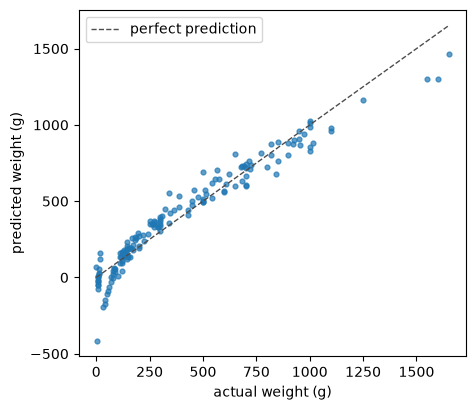

15 fish have a negative predicted weight; the lowest is -415 g


In [64]:
import matplotlib.pyplot as plt

predicted = reg1.predict(x_new)
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(y_mtx, predicted, s=12, alpha=0.7)
ax.plot([0, y_mtx.max()], [0, y_mtx.max()], color='.3', ls='--', lw=1, label='perfect prediction')
ax.set_xlabel('actual weight (g)')
ax.set_ylabel('predicted weight (g)')
ax.legend()
plt.show()

print((predicted < 0).sum(), 'fish have a negative predicted weight; the lowest is', round(predicted.min()), 'g')

The points bend away from the dashed line: the model underestimates the smallest and largest fish, overestimates the ones in between, and predicts a negative weight for 15 fish. Weight grows like volume, which multiplies length, height, and width together, and a linear model can only add them up. This is the Anscombe's quartet problem again, with real data: a high $R^2$ doesn't mean the model has the right shape.

### Getting Fancy
We can also use something called a *kernel function* to transform our linear data into higher dimensional space. Specifically, we can apply arbitrary functions to our fish data and add them to our linear regression matrices. Let's say we have two concentric circles as a dataset:
![Concentric circles](images/concentric_circles.png)
We're going to have a hard time separating these with either of their $x$ and $y$ coordinates! But what if we add a new column that is $\sqrt{x_i^2 + y_i^2}$? We're able to separate them easily because we've projected our points into a higher dimensional space. Neat!!

Let's try applying this to the fish dataset. Can you engineer a new column for the fish dataset that improves your $R^2$?

In [45]:
# Your Turn!

#### The cube law
If fish kept the same shape as they grew, weight would grow like length cubed: $W = cL^3$. Taking logs turns that into a straight line, $\log W = 3\log L + \log c$, so a regression of $\log W$ on $\log L$ should have a slope near 3. One fish in the file weighs 0 g, and $\log 0$ is undefined, so we drop it first:

1 fish dropped
slope: 3.168709724276616


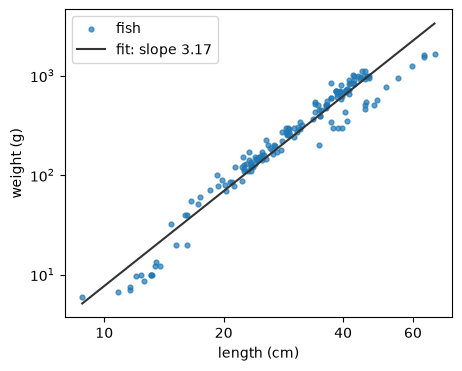

In [46]:
fish = df_fish[df_fish['Weight'] > 0]
print(len(df_fish) - len(fish), 'fish dropped')

log_reg = linear_model.LinearRegression()
log_reg.fit(np.log(fish[['Length3']]), np.log(fish['Weight']))
print('slope:', log_reg.coef_[0])

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(fish['Length3'], fish['Weight'], s=12, alpha=0.7, label='fish')
L = np.linspace(fish['Length3'].min(), fish['Length3'].max(), 100)
ax.plot(L, np.exp(log_reg.intercept_) * L ** log_reg.coef_[0], color='.2',
        label=f'fit: slope {log_reg.coef_[0]:.2f}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks([10, 20, 40, 60], labels=['10', '20', '40', '60'])
ax.minorticks_off()
ax.set_xlabel('length (cm)')
ax.set_ylabel('weight (g)')
ax.legend()
plt.show()

Fitting a straight line on log–log axes is fine here, where we predict one measurement from another. It's the wrong way to fit a power-law degree distribution; for that, use maximum likelihood (Clauset, Shalizi & Newman, 2009).

#### Uncertainty with `statsmodels`
`sklearn` is built for prediction: it gives you coefficients but no uncertainty, and for science you usually want to know how precise a coefficient is. `statsmodels` gives you that. Its formulas also handle categories for you: `C(Species)` makes the dummy columns and drops one of them, so they don't duplicate the intercept.

In [47]:
import statsmodels.formula.api as smf

model = smf.ols('np.log(Weight) ~ np.log(Length3) + C(Species)', data=fish).fit()
print(model.summary().tables[1])

                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                  -5.1276      0.137    -37.518      0.000      -5.398      -4.858
C(Species)[T.Parkki]        0.2190      0.043      5.134      0.000       0.135       0.303
C(Species)[T.Perch]         0.0692      0.026      2.638      0.009       0.017       0.121
C(Species)[T.Pike]         -0.7068      0.033    -21.137      0.000      -0.773      -0.641
C(Species)[T.Roach]        -0.0529      0.035     -1.508      0.134      -0.122       0.016
C(Species)[T.Smelt]        -0.6013      0.053    -11.346      0.000      -0.706      -0.497
C(Species)[T.Whitefish]     0.1401      0.049      2.885      0.004       0.044       0.236
np.log(Length3)             3.1565      0.037     84.878      0.000       3.083       3.230


With species in the model, the slope is 3.16, with a 95% confidence interval from 3.08 to 3.23. That's close to 3, but the interval doesn't include it: in this data, bigger fish are a little heavier for their length than a scaled-up small fish would be. Each species row compares that species with bream, the first alphabetically. The coefficients are on the log scale, so pike's −0.71 means a pike weighs about half as much as a bream of the same length ($e^{-0.71} \approx 0.49$).

__________
## Next time...
Community Detection 1 — Traditional! `class_07_communities1.ipynb`
_______

## References and further resources:

1. Class Webpages
    - Jupyter Book: https://computational-methods-network-science.github.io/nets7052_fa26/README.html
    - Github: https://github.com/computational-methods-network-science/nets7052_fa26/
    - Syllabus and course details: https://brennanklein.com/nets7052-fall26
2. Our intro to `pandas` borrows heavily from [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)
3. Our whale dataset comes from the [UK Polar Data Centre](https://ramadda.data.bas.ac.uk/repository/entry/show?entryid=c1afe32c-493c-4dc7-af9f-649593b97b2c)
4. Our fish dataset is sourced from [Kaggle](https://www.kaggle.com/datasets/vipullrathod/fish-market)
5. The kernel function image comes from the [Carpentries Incubator](https://carpentries-incubator.github.io/machine-learning-novice-sklearn/04-clustering/index.html)
6. For more on kernel methods, check out [this textbook chapter](https://people.eecs.berkeley.edu/~jordan/kernels/0521813972c02_p25-46.pdf)
7. The Florida Bay food web comes from Ulanowicz, R. E., Bondavalli, C., & Egnotovich, M. S. (1998). *Network analysis of trophic dynamics in South Florida ecosystem, FY 97: The Florida Bay ecosystem*. Annual Report to the United States Geological Service Biological Resources Division, Chesapeake Biological Laboratory, University of Maryland.